<a href="https://colab.research.google.com/github/nema78/capstone_-project/blob/main/ecommerce_customer_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

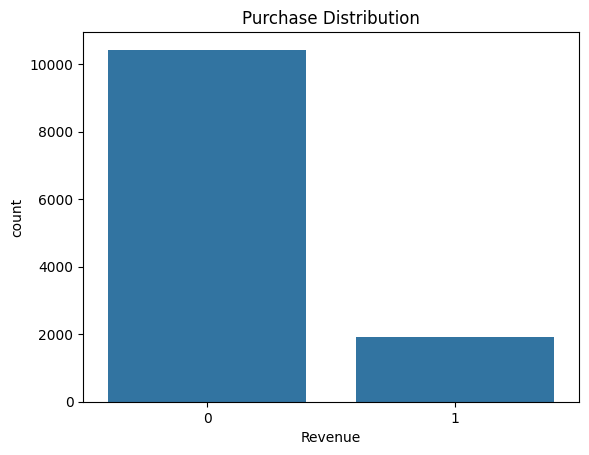

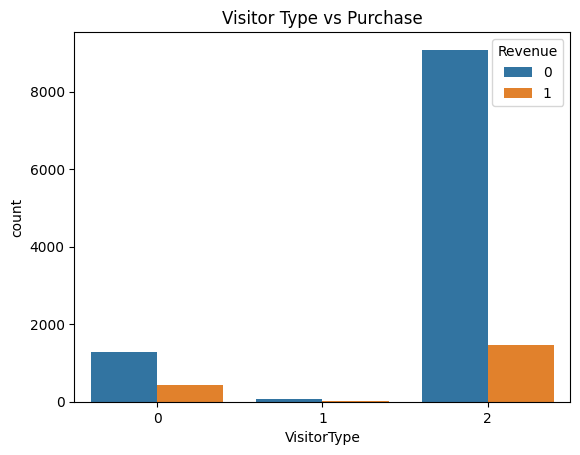

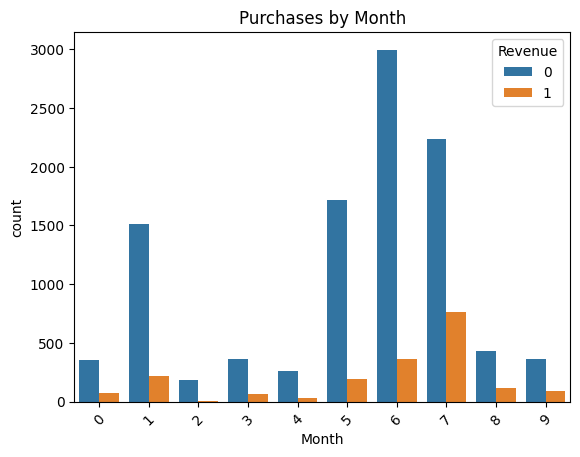

 Insight: Certain months show higher purchasing activity, indicating seasonal trends.


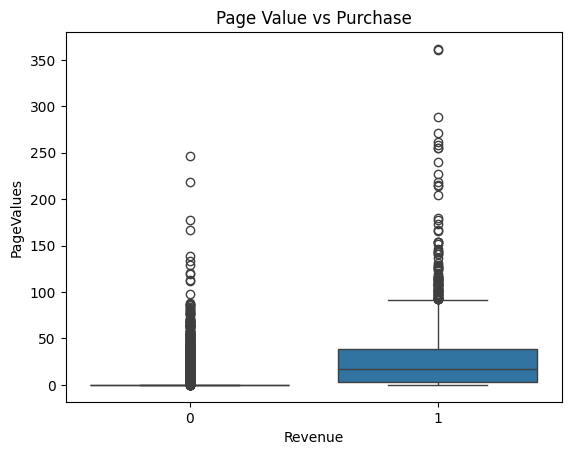

 Insight: Visitors with higher page values are significantly more likely to make purchases.


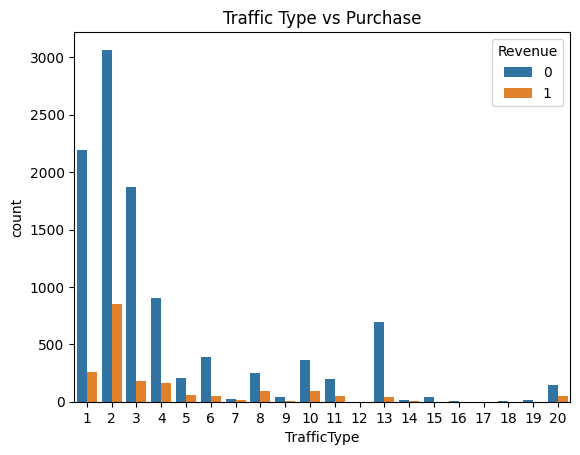

 Insight: Some traffic sources bring visitors who are more likely to convert.


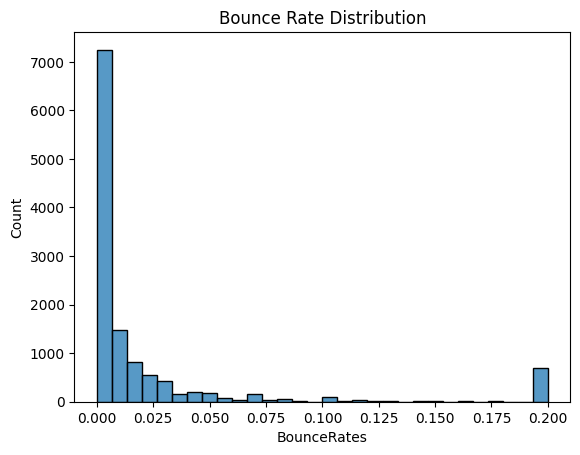

 Insight: Most users have low bounce rates, but high bounce rates correlate with fewer purchases.


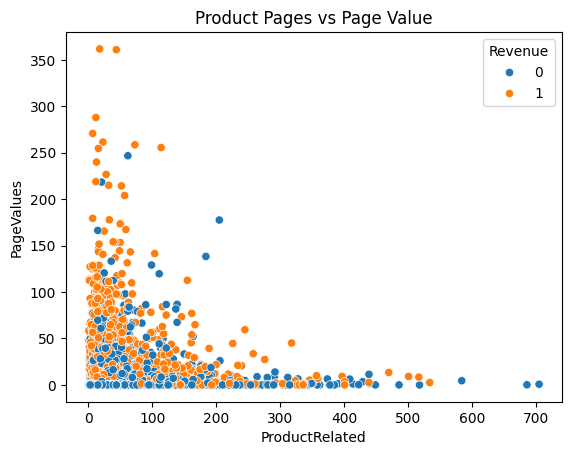

 Insight: Users who view more product pages often generate higher page values and purchasing probability.


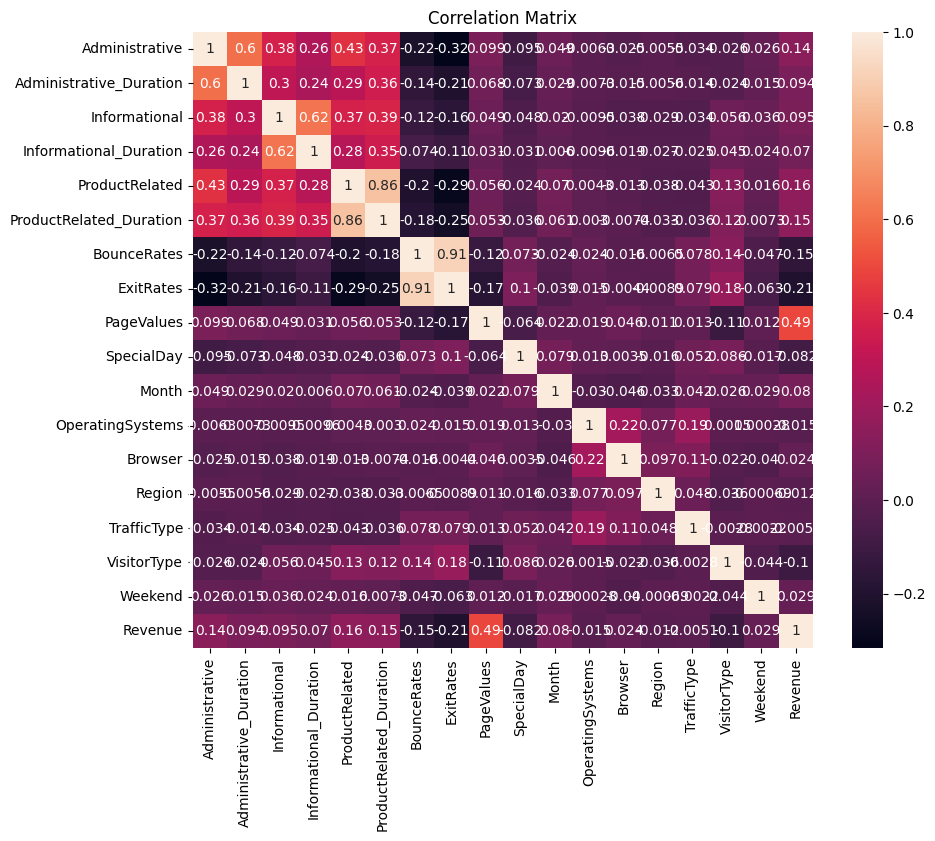

Logistic Regression Accuracy: 0.8690186536901865
Random Forest Accuracy: 0.8925385239253852
Accuracy: 0.8690186536901865
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      2055
           1       0.74      0.55      0.63       411

    accuracy                           0.89      2466
   macro avg       0.83      0.75      0.78      2466
weighted avg       0.88      0.89      0.89      2466



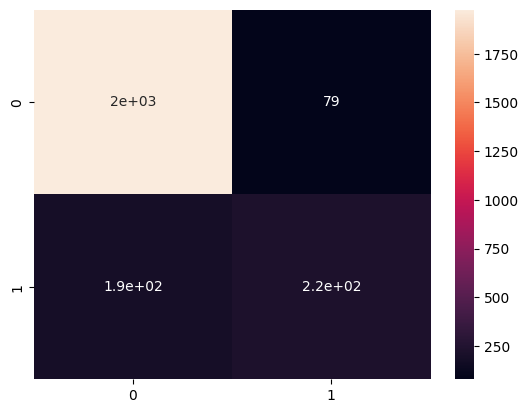

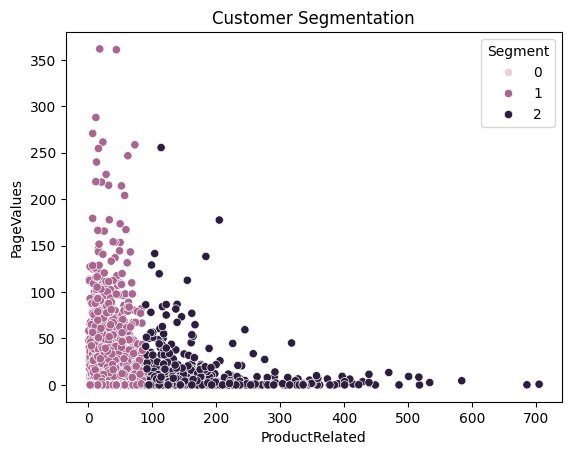

In [14]:
# E-Commerce Customer Behavior Analysis
# Predicting Online Purchase Intention Using Machine Learning

# Author: Nema Aly
# Tools: Python, Pandas, Scikit-learn, Matplotlib, Seaborn

## 1-Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## 2-Load Dataset

df = pd.read_csv("online_shoppers_intention.csv")

df.head()

## 3-Data Overview

df.info()
df.describe()

## 4-Check Missing Values

df.isnull().sum()

## 5=Data Processing

le = LabelEncoder()

df["Month"] = le.fit_transform(df["Month"])
df["VisitorType"] = le.fit_transform(df["VisitorType"])
df["Weekend"] = le.fit_transform(df["Weekend"])
df["Revenue"] = le.fit_transform(df["Revenue"])

## 6-Data Visualization + Insights

# Chart 1 - Purchase Distribution
sns.countplot(x="Revenue", data=df)

plt.title("Purchase Distribution")

plt.show()

# Chart 2 - Visitor Type vs Purchase
sns.countplot(x="VisitorType", hue="Revenue", data=df)

plt.title("Visitor Type vs Purchase")

plt.show()

# Chart 3 – Monthly Purchases
sns.countplot(x="Month", hue="Revenue", data=df)
plt.title("Purchases by Month")
plt.xticks(rotation=45)
plt.show()
print(" Insight: Certain months show higher purchasing activity, indicating seasonal trends.")

# Chart 4 – Page Value vs Purchase
sns.boxplot(x="Revenue", y="PageValues", data=df)
plt.title("Page Value vs Purchase")
plt.show()
print(" Insight: Visitors with higher page values are significantly more likely to make purchases.")

# Chart 5 – Traffic Type vs Purchase
sns.countplot(x="TrafficType", hue="Revenue", data=df)
plt.title("Traffic Type vs Purchase")
plt.show()
print(" Insight: Some traffic sources bring visitors who are more likely to convert.")

# Chart 6 – Bounce Rate Distribution
sns.histplot(df["BounceRates"], bins=30)
plt.title("Bounce Rate Distribution")
plt.show()
print(" Insight: Most users have low bounce rates, but high bounce rates correlate with fewer purchases.")

# Chart 7 – Page Value vs Product Pages
sns.scatterplot(x="ProductRelated", y="PageValues", hue="Revenue", data=df)
plt.title("Product Pages vs Page Value")
plt.show()
print(" Insight: Users who view more product pages often generate higher page values and purchasing probability.")

#Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Matrix")

plt.show()

## 7- Machine Learning

#Prepare Data
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("Accuracy:", accuracy_score(y_test, lr_pred))


#Model Evaluation
print(classification_report(y_test, rf_pred))


#Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True)

plt.show()

## 8-Customer Segmentation
# Clustering
features = df[["ProductRelated","PageValues","BounceRates"]]

scaler = StandardScaler()

scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3)

df["Segment"] = kmeans.fit_predict(scaled)

#Visualization
sns.scatterplot(
    x="ProductRelated",
    y="PageValues",
    hue="Segment",
    data=df
)

plt.title("Customer Segmentation")

plt.show()

## 9- Generative AI Usage

# Generative AI was used in this project in three ways:

# 1. Ideation and Research: Assisted in brainstorming the project idea and refining the problem statement for predicting online customer purchasing behavior.

 # 2. Coding and Development: Provided guidance for writing and debugging Python code for data processing, visualization, and machine learning models.

 # 3. Documentation and Insights: Helped summarize analytical findings and generate explanations for the results.

 #Using Generative AI improved productivity and helped translate technical analysis into clear insights.


## 10. Business Insights & Recommendations

 # Key insights:

# 1. Returning visitors are more likely to make a purchase.
# 2. Visitors who view more product pages show higher purchasing probability.
# 3. Lower bounce rates correlate with higher purchase rates.

# Recommendations:

 # 1- Target returning visitors with personalized promotions.
 # 2- Improve product page engagement to encourage browsing.
 # 3- Optimize website navigation to reduce bounce rates.
 # 4- Use predictive models to identify high-value visitors for marketing campaigns.


# Conclusion

#This project demonstrated how data analysis and machine learning can be used to understand customer behavior in e-commerce environments.

#The results showed that user engagement metrics such as product page visits and page value strongly influence purchasing decisions.

#These insights can help businesses improve marketing strategies and increase conversion rates.


## 9- Generative AI Usage

 Generative AI was used in this project in three ways:

 1. Ideation and Research: Assisted in brainstorming the project idea and refining the problem statement for predicting online customer purchasing behavior.

 2. Coding and Development: Provided guidance for writing and debugging Python code for data processing, visualization, and machine learning models.

 3. Documentation and Insights: Helped summarize analytical findings and generate explanations for the results.


 Using Generative AI improved productivity and helped translate technical analysis into clear insights.


## 10. Business Insights & Recommendations

  Key insights:

 1. Returning visitors are more likely to make a purchase.
 2. Visitors who view more product pages show higher purchasing probability.
 3. Lower bounce rates correlate with higher purchase rates.

 Recommendations:

  1- Target returning visitors with personalized promotions.
  2- Improve product page engagement to encourage browsing.
  3- Optimize website navigation to reduce bounce rates.
  4- Use predictive models to identify high-value visitors for marketing campaigns.


# Conclusion

This project demonstrated how data analysis and machine learning can be used to understand customer behavior in e-commerce environments.

The results showed that user engagement metrics such as product page visits and page value strongly influence purchasing decisions.

These insights can help businesses improve marketing strategies and increase conversion rates.
